In [ ]:
!pip install unsloth

## Load Data: Politifact Dataset

In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

def load_and_split_data(file_path="/content/politifact_factcheck_data.json", output_dir='data_splits'):
    """
    Reads the PolitiFact JSON data and splits it into training, validation, and test sets.

    This method loads data from a JSON file into a pandas DataFrame. It then performs
    a stratified split to ensure that the training, validation, and test sets have a
    similar distribution of the target variable ('verdict').

    Args:
        file_path (str): The path to the JSON data file.

    Returns:
        tuple: A tuple containing three pandas DataFrames: (train_df, val_df, test_df).
               Returns (None, None, None) if the file cannot be read.
    """
    print(f"Attempting to load data from {file_path}...")

    try:
        # Load the JSON data into a pandas DataFrame
        data_df = pd.read_json(file_path,lines=True)
    except Exception as e:
        print(f"Error: Could not read the file {file_path}. Please check the file path and format.")
        print(f"Details: {e}")
        return None, None, None

    # Identify the target column for stratification. Assumes the label is in 'verdict'.
    # If 'verdict' column doesn't exist, stratification is skipped.
    target_col = 'verdict' if 'verdict' in data_df.columns else None
    stratify_data = data_df[target_col] if target_col else None

    # Split the data: 80% train, 20% temporary (for validation and test)
    train_df, temp_df = train_test_split(
        data_df,
        test_size=0.2,
        random_state=42,  # for reproducibility
        stratify=stratify_data
    )

    # Re-check for stratification in the smaller temporary dataframe
    stratify_temp_data = temp_df[target_col] if target_col else None

    # Split the temporary data: 50% validation, 50% test (10% of total each)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=42,  # for reproducibility
        stratify=stratify_temp_data
    )

    print("Data successfully split:")
    print(f"  Training set size:   {len(train_df)} records")
    print(f"  Validation set size: {len(val_df)} records")
    print(f"  Test set size:       {len(test_df)} records")

    # --- ADDED LINES TO SAVE THE FILES ---
    try:
        # Create the output directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)

        # Define file paths
        train_path = os.path.join(output_dir, 'train_data.csv')
        val_path = os.path.join(output_dir, 'validation_data.csv')
        test_path = os.path.join(output_dir, 'test_data.csv')

        # Save the DataFrames to CSV, without the pandas index
        train_df.to_csv(train_path, index=False)
        val_df.to_csv(val_path, index=False)
        test_df.to_csv(test_path, index=False)

        print("\nData splits saved successfully: ")
        print(f"  - Training data:   {train_path}")
        print(f"  - Validation data: {val_path}")
        print(f"  - Test data:       {test_path}")

    except Exception as e:
        print(f"\nError saving files: {e}")

    return train_df, val_df, test_df

load_and_split_data()

Attempting to load data from /content/politifact_factcheck_data.json...
Data successfully split:
  Training set size:   16921 records
  Validation set size: 2115 records
  Test set size:       2116 records

Data splits saved successfully: ✅
  - Training data:   data_splits/train_data.csv
  - Validation data: data_splits/validation_data.csv
  - Test data:       data_splits/test_data.csv


(            verdict                      statement_originator  \
 7055          false                             Thomas Sowell   
 6897    mostly-true                              Donald Trump   
 15293    pants-fire  National Republican Senatorial Committee   
 17610    pants-fire                               Viral image   
 11914         false                             Shawn Lindsay   
 ...             ...                                       ...   
 17355         false                             Chris Kapenga   
 20032          true                               Viral image   
 6951          false                    Marjorie Taylor Greene   
 6972   mostly-false                              Brett Hulsey   
 15202         false                           Instagram posts   
 
                                                statement statement_date  \
 7055   The Obama administration "was successful in ru...       9/8/2009   
 6897   "The top man at Yale Law School came out ... w

## Basic Configuration

In [ ]:
import pandas as pd
import os
import logging
import re
import string
import torch
import torch.nn.functional as F
from datasets import Dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments, pipeline, Trainer, AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- File & Directory Paths ---
TRAIN_CSV = 'data_splits/train_data.csv'
VAL_CSV = 'data_splits/validation_data.csv'
TEST_CSV = 'data_splits/test_data.csv'
TEACHER_MODEL_DIR = "results_nrfe_teacher"
STUDENT_MODEL_DIR = "results_nrfe_distilled_student"
AUGMENTATION

# --- Column & Model Names ---
TEXT_COLUMN = 'text_cleaned'
# The Teacher model should be powerful
TEACHER_MODEL_NAME = "unsloth/llama-3.2-1b-bnb-4bit"
# The Student model can be smaller and more efficient
STUDENT_MODEL_NAME = "distilbert-base-uncased"

# --- Prompts for Augmentation ---
POSITIVE_PROMPT = "Provide a brief, plausible-sounding reason why the following statement might be considered true: \"{text}\""
NEGATIVE_PROMPT = "Provide a brief, plausible-sounding reason why the following statement might be considered false: \"{text}\""

# --- Distillation Hyperparameters ---
DISTILLATION_TEMP = 2.0  # Temperature for softening probabilities
DISTILLATION_ALPHA = 0.5 # Weight for the hard label loss (CrossEntropy)

## Load and Preprocess Data

In [ ]:

def clean_text(text):
    if not isinstance(text, str): return ""
    return re.sub(r'\s+', ' ', text.lower().translate(str.maketrans('', '', string.punctuation))).strip()

def map_verdict_to_binary(verdict):
    return 0 if verdict in ['pants-fire', 'false'] else 1 # 0 for FAKE, 1 for REAL

def load_and_preprocess_data(train_path, val_path, test_path):
    """Loads and processes train, validation, and test sets separately."""
    print("🔄 Step 1: Loading and preprocessing data...")
    try:
        train_df = pd.read_csv(train_path)
        val_df = pd.read_csv(val_path)
        test_df = pd.read_csv(test_path)
        for df in [train_df, val_df, test_df]:
            df.rename(columns={'statement': 'text_cleaned'}, inplace=True)
            df['text_cleaned'] = df['text_cleaned'].apply(clean_text)
            df['label_numeric'] = df['verdict'].apply(map_verdict_to_binary)
        print(" Data loading complete.")
        return train_df, val_df, test_df
    except FileNotFoundError as e:
        logging.error(f"Error: {e}. Make sure data files are uploaded.")
        return None, None, None


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## Augmentation of the dataset with positive and negative prompts

In [ ]:
def run_augmentation(model, tokenizer, train_df):
    """Generates positive and negative reasoning for the training set."""
    print(" Step 2: Augmenting training data with reasoning...")
    pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, max_new_tokens=64, batch_size=16)
    source_texts = train_df[TEXT_COLUMN].tolist()
    pos_prompts = [POSITIVE_PROMPT.format(text=text) for text in source_texts]
    neg_prompts = [NEGATIVE_PROMPT.format(text=text) for text in source_texts]
    train_df['positive_reasoning'] = [res[0]['generated_text'].split('\n')[-1] for res in tqdm(pipe(pos_prompts), desc="Positive Reasoning")]
    train_df['negative_reasoning'] = [res[0]['generated_text'].split('\n')[-1] for res in tqdm(pipe(neg_prompts), desc="Negative Reasoning")]
    print("Augmentation complete.")
    train_df.to_csv("data_splits/train_data_augmented.csv")
    return train_df



## NRFE Teacher - Student
### Formatting data for Teacher (NRFE) model training


In [ ]:
def create_teacher_training_data(augmented_train_df):
    """Formats data for the NRFE (Teacher) model."""
    records = []
    for _, row in augmented_train_df.iterrows():
        # Case 1: Positive reasoning
        records.append({
            "instruction": "Evaluate the following news statement based on the provided reasoning. Determine if the statement is REAL or FAKE.",
            "input": f"Statement: \"{row['text_cleaned']}\"\nReasoning: \"{row['positive_reasoning']}\"",
            "output": "REAL" if row['label_numeric'] == 1 else "FAKE"
        })
        # Case 2: Negative reasoning
        records.append({
            "instruction": "Evaluate the following news statement based on the provided reasoning. Determine if the statement is REAL or FAKE.",
            "input": f"Statement: \"{row['text_cleaned']}\"\nReasoning: \"{row['negative_reasoning']}\"",
            "output": "FAKE" if row['label_numeric'] == 1 else "REAL" # Flipped label
        })
    return pd.DataFrame(records)


### Fine-tuning Teacher (NRFE) model

In [ ]:
def run_teacher_finetuning(model, tokenizer, train_df):
    """Fine-tunes the Teacher (NRFE) model."""
    def format_prompt(example):
        """Alpaca-style prompt formatting."""
        return f"""### Instruction:\n{example['instruction']}\n\n### Input:\n{example['input']}\n\n### Response:\n{example['output']}"""

    model = FastLanguageModel.get_peft_model(
        model, r=16, target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_alpha=16, lora_dropout=0, bias="none", use_gradient_checkpointing=True,
    )
    dataset = Dataset.from_pandas(train_df).map(lambda x: {"text": format_prompt(x)})
    trainer = SFTTrainer(
        model=model, tokenizer=tokenizer, train_dataset=dataset, dataset_text_field="text", max_seq_length=2048,
        args=TrainingArguments(
            per_device_train_batch_size=2, gradient_accumulation_steps=4, warmup_steps=10, num_train_epochs=3,
            learning_rate=2e-4, fp16=not torch.cuda.is_bf16_supported(), bf16=torch.cuda.is_bf16_supported(),
            logging_steps=1, optim="adamw_8bit", weight_decay=0.01, lr_scheduler_type="linear", seed=42,
            output_dir=TEACHER_MODEL_DIR,
        ),
    )
    print("Training initiated")
    trainer.train()
    print("Teacher model fine-tuning complete!")
    model.save_pretrained(TEACHER_MODEL_DIR)
    tokenizer.save_pretrained(TEACHER_MODEL_DIR)
    print(f"Saved final teacher model to '{TEACHER_MODEL_DIR}'.")

### Generating soft labels from Teacher model

In [ ]:
def format_teacher_prompt(example):
    return f"""### Instruction:\n{example['instruction']}\n\n### Input:\n{example['input']}\n\n### Response:\n{example['output']}"""

def generate_teacher_logits(teacher_model, tokenizer, train_df):
    """Uses the trained teacher to generate soft labels (logits) for the student."""
    pipe = pipeline("text-generation", model=teacher_model, tokenizer=tokenizer, max_new_tokens=5, batch_size=16)
    teacher_logits = []

    # This is a mock implementation. A full implementation would extract actual logits.
    for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Getting Teacher Logits"):
        # Correctly format the prompt for inference
        prompt = format_teacher_prompt({
            "instruction": "Evaluate the following news statement based on the provided reasoning. Determine if the statement is REAL or FAKE.",
            "input": f"Statement: \"{row['text_cleaned']}\"\nReasoning: \"{row['positive_reasoning']}\"",
            "output": "" # Output is empty for inference
        })

        # Robust parsing of the model's response
        result = pipe(prompt)
        full_response = result[0]['generated_text']

        prediction = ""
        if "### Response:" in full_response:
            prediction = full_response.split("### Response:")[1].strip()
        else:
            # Fallback: assume the generated text after the prompt is the prediction
            prediction = full_response.replace(prompt.replace("### Response:", ""), "").strip()

        if "REAL" in prediction:
            teacher_logits.append([0.1, 0.9]) # Soft label strongly favoring REAL
        else:
            teacher_logits.append([0.9, 0.1]) # Soft label strongly favoring FAKE

    train_df['teacher_logits'] = teacher_logits
    print("Soft labels generated.")
    return train_df


### Custom Trainer for Knowledge Distillation

In [ ]:
class DistillationTrainer(Trainer):
    """Custom Trainer for Knowledge Distillation."""
    # The signature is updated to accept **kwargs
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Get outputs from the student model
        student_outputs = model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'])
        student_logits = student_outputs.logits

        # Get teacher logits and hard labels from the input dataset
        teacher_logits = inputs.get("teacher_logits")
        hard_labels = inputs.get("labels")

        # 1. Distillation Loss (KL-Divergence)
        soft_loss = F.kl_div(
            F.log_softmax(student_logits / DISTILLATION_TEMP, dim=-1),
            F.softmax(teacher_logits / DISTILLATION_TEMP, dim=-1),
            reduction="batchmean"
        ) * (DISTILLATION_TEMP ** 2)

        # 2. Student Loss (Cross-Entropy)
        hard_loss = F.cross_entropy(student_logits, hard_labels)

        # Combine the two losses
        loss = DISTILLATION_ALPHA * hard_loss + (1 - DISTILLATION_ALPHA) * soft_loss

        return (loss, student_outputs) if return_outputs else loss


### Fine-tuning Student (NRFE-D) model on distillation examples

In [ ]:

def run_student_finetuning(distillation_df):
    """Fine-tunes the Student (NRFE-D) model."""
    student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL_NAME)
    student_model = AutoModelForSequenceClassification.from_pretrained(STUDENT_MODEL_NAME, num_labels=2)

    def tokenize_function(examples):
        return student_tokenizer(examples["text_cleaned"], padding="max_length", truncation=True)

    distillation_df = distillation_df.rename(columns={'label_numeric': 'labels'})
    dataset = Dataset.from_pandas(distillation_df)
    tokenized_dataset = dataset.map(tokenize_function, batched=True)

    # This ensures the columns are tensors, which is still necessary
    tokenized_dataset.set_format(
        "torch", columns=["input_ids", "attention_mask", "labels", "teacher_logits"]
    )

    training_args = TrainingArguments(
        output_dir=STUDENT_MODEL_DIR,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_dir='./logs',
        # --- THIS IS THE FIX ---
        # This tells the Trainer to keep all columns from the dataset,
        # including our custom 'teacher_logits' column.
        remove_unused_columns=False,
    )

    trainer = DistillationTrainer(
        model=student_model,
        args=training_args,
        train_dataset=tokenized_dataset,
    )

    print("Distillation training initiated")
    trainer.train()
    print("Student model fine-tuning complete!")
    trainer.save_model(STUDENT_MODEL_DIR)
    student_tokenizer.save_pretrained(STUDENT_MODEL_DIR)
    print(f"Saved final student model to '{STUDENT_MODEL_DIR}'.")

In [ ]:
def main():
    """Main function to execute the full Teacher-Student workflow."""
    print("--- Starting Full Workflow for NRFE Teacher and NRFE-D Student ---")

    # --- Teacher Model Training ---
    teacher_model, teacher_tokenizer = FastLanguageModel.from_pretrained(
        model_name=TEACHER_MODEL_NAME, max_seq_length=2048, dtype=None, load_in_4bit=True,
    )
    train_df, _, _ = load_and_preprocess_data(TRAIN_CSV, VAL_CSV, TEST_CSV)
    if train_df is None: return

    # --- ADD THIS LINE TO TEST ON 100 SAMPLES ---
    train_df = train_df.head(100).copy()
    print(f"\n TESTING ON A SMALL SUBSET of {len(train_df)} records.\n")

    augmented_train_df = run_augmentation(teacher_model, teacher_tokenizer, train_df)
    teacher_train_ready_df = create_teacher_training_data(augmented_train_df)
    run_teacher_finetuning(teacher_model, teacher_tokenizer, teacher_train_ready_df)

    # --- Student Model Training (Distillation) ---
    # Reload the trained teacher model
    print("\n--- Reloading trained teacher model for distillation step ---")
    teacher_model, teacher_tokenizer = FastLanguageModel.from_pretrained(
        model_name=TEACHER_MODEL_DIR, max_seq_length=2048, dtype=None, load_in_4bit=True,
    )
    distillation_df = generate_teacher_logits(teacher_model, teacher_tokenizer, augmented_train_df)
    run_student_finetuning(distillation_df)

    print(" All steps completed successfully!")

# To run: Call main() in your notebook after installing unsloth and transformers.

In [ ]:
main()

--- Starting Full Workflow for NRFE Teacher and NRFE-D Student ---
==((====))==  Unsloth 2025.7.8: Fast Llama patching. Transformers: 4.53.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.3.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.31.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.03G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

...

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

🔥 Distillation training initiated...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 100 | Num Epochs = 3 | Total steps = 21
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 66,955,010 of 66,955,010 (100.00% trained)


Step,Training Loss


✅ Student model fine-tuning complete!
💾 Saved final student model to 'results_nrfe_distilled_student'.
🎉 All steps completed successfully!


##Evaluation NRFE-D

--- Running evaluation on a sample of 100 records ---
---  evaluating teacher (nrfe) model ---
Loading base model to generate reasoning...
==((====))==  Unsloth 2025.7.8: Fast Llama patching. Transformers: 4.53.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.3.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.31.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Device set to use cuda:0


Positive Reasoning:   0%|          | 0/100 [00:00<?, ?it/s]

Negative Reasoning:   0%|          | 0/100 [00:00<?, ?it/s]

Loading fine-tuned Teacher model from 'results_nrfe_teacher'...
==((====))==  Unsloth 2025.7.8: Fast Llama patching. Transformers: 4.53.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.3.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.31.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


...

  0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Device set to use cuda:0



--- 📊 teacher (nrfe) model metrics ---
              precision    recall  f1-score   support

        FAKE       0.50      1.00      0.67       100
        REAL       0.00      0.00      0.00       100

    accuracy                           0.50       200
   macro avg       0.25      0.50      0.33       200
weighted avg       0.25      0.50      0.33       200


--- evaluating student (nrfe-d) model ---
Loading fine-tuned Student model from 'results_nrfe_distilled_student'...
Running inference on 100 validation statements for the Student model...


  0%|          | 0/100 [00:00<?, ?it/s]


--- 📊 student (nrfe-d) model metrics ---

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.47      0.93      0.63        44
        REAL       0.77      0.18      0.29        56

    accuracy                           0.51       100
   macro avg       0.62      0.56      0.46       100
weighted avg       0.64      0.51      0.44       100



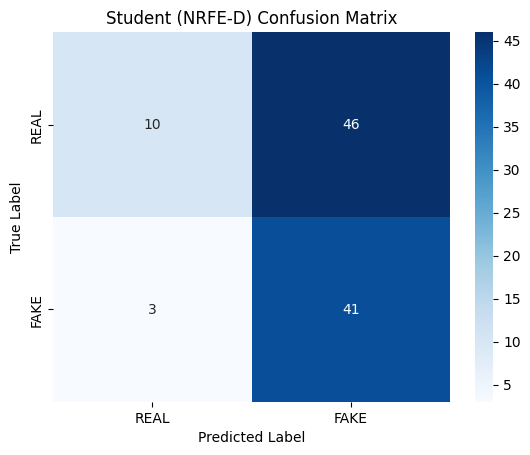


--- 🔍 comparative error analysis ---

Found 0 examples where the Student failed but the Teacher succeeded.


In [ ]:

import pandas as pd
import os
import logging
import re
import string
import torch
from unsloth import FastLanguageModel
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

VAL_CSV = 'data_splits/validation_data.csv'
TEACHER_MODEL_DIR = "results_nrfe_teacher"
STUDENT_MODEL_DIR = "results_nrfe_distilled_student"
BASE_TEACHER_MODEL = "unsloth/llama-3.2-1b-bnb-4bit" # The base model used to train the teacher

# --- Column & Prompt Names ---
TEXT_COLUMN = 'text_cleaned'
POSITIVE_PROMPT = "Provide a brief, plausible-sounding reason why the following statement might be considered true: \"{text}\""
NEGATIVE_PROMPT = "Provide a brief, plausible-sounding reason why the following statement might be considered false: \"{text}\""





In [ ]:
## Helpers
def clean_text(text):
    if not isinstance(text, str): return ""
    return re.sub(r'\s+', ' ', text.lower().translate(str.maketrans('', '', string.punctuation))).strip()

def map_verdict_to_binary(verdict):
    return 0 if verdict in ['pants-fire', 'false'] else 1 # 0 for FAKE, 1 for REAL

def format_teacher_prompt(instruction, input_text):
    """Formats prompts for the Teacher (NRFE) model for inference."""
    return f"""### Instruction:\n{instruction}\n\n### Input:\n{input_text}\n\n### Response:"""

def robust_parsing(full_response, prompt):
    """Safely extracts the prediction from the model's full output."""
    if "### Response:" in full_response:
        return full_response.split("### Response:")[1].strip()
    else:
        # Fallback: assume the generated text after the prompt is the prediction
        return full_response.replace(prompt.replace("### Response:", ""), "").strip()

In [ ]:
#Main functions
def evaluate_teacher_model(val_df):
    """Loads and evaluates the fine-tuned Teacher (NRFE) model."""
    print("---  evaluating teacher (nrfe) model ---")

    # 1. Load base model to generate reasoning
    print("Loading base model to generate reasoning...")
    base_model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_TEACHER_MODEL, max_seq_length=2048, dtype=None, load_in_4bit=True,
    )
    reasoning_pipe = pipeline("text-generation", model=base_model, tokenizer=tokenizer, max_new_tokens=64, batch_size=16)

    val_texts = val_df[TEXT_COLUMN].tolist()
    pos_prompts = [POSITIVE_PROMPT.format(text=text) for text in val_texts]
    neg_prompts = [NEGATIVE_PROMPT.format(text=text) for text in val_texts]
    val_df['positive_reasoning'] = [res[0]['generated_text'].split('\n')[-1] for res in tqdm(reasoning_pipe(pos_prompts), desc="Positive Reasoning")]
    val_df['negative_reasoning'] = [res[0]['generated_text'].split('\n')[-1] for res in tqdm(reasoning_pipe(neg_prompts), desc="Negative Reasoning")]

    # 2. Load the fine-tuned Teacher model
    print(f"Loading fine-tuned Teacher model from '{TEACHER_MODEL_DIR}'...")
    teacher_model, teacher_tokenizer = FastLanguageModel.from_pretrained(
        model_name=TEACHER_MODEL_DIR, max_seq_length=2048, dtype=None, load_in_4bit=True,
    )
    teacher_pipe = pipeline("text-generation", model=teacher_model, tokenizer=teacher_tokenizer, max_new_tokens=5, batch_size=16)

    # 3. Prepare prompts and get predictions
    prompts_to_test, true_labels = [], []
    for _, row in val_df.iterrows():
        prompts_to_test.append(format_teacher_prompt("...", f"Statement: \"{row[TEXT_COLUMN]}\"\nReasoning: \"{row['positive_reasoning']}\""))
        true_labels.append("REAL" if row['label_numeric'] == 1 else "FAKE")
        prompts_to_test.append(format_teacher_prompt("...", f"Statement: \"{row[TEXT_COLUMN]}\"\nReasoning: \"{row['negative_reasoning']}\""))
        true_labels.append("FAKE" if row['label_numeric'] == 1 else "REAL")

    print(f"Running inference on {len(prompts_to_test)} validation examples for the Teacher model...")
    results = teacher_pipe(prompts_to_test)
    predictions = [robust_parsing(res[0]['generated_text'], prompt) for res, prompt in zip(tqdm(results), prompts_to_test)]
    valid_predictions = [p if p in ['REAL', 'FAKE'] else 'FAKE' for p in predictions]

    # 4. Display metrics
    print("\n--- teacher (nrfe) model metrics ---")
    print(classification_report(true_labels, valid_predictions, target_names=['FAKE', 'REAL']))
    return true_labels, valid_predictions

def evaluate_student_model(val_df):
    """Loads and evaluates the distilled Student (NRFE-D) model."""
    print("\n--- evaluating student (nrfe-d) model ---")

    # 1. Load the fine-tuned Student model and tokenizer
    print(f"Loading fine-tuned Student model from '{STUDENT_MODEL_DIR}'...")
    student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL_DIR)
    student_model = AutoModelForSequenceClassification.from_pretrained(STUDENT_MODEL_DIR)

    pipe = pipeline("text-classification", model=student_model, tokenizer=student_tokenizer, device=0)

    # 2. Get predictions
    statements_to_test = val_df[TEXT_COLUMN].tolist()
    print(f"Running inference on {len(statements_to_test)} validation statements for the Student model...")
    results = pipe(statements_to_test)

    # --- THIS IS THE FIX ---
    # The model outputs generic labels like 'LABEL_0'. We must map them to our desired labels.
    # Assuming the standard mapping where 0 is the first label, 1 is the second.
    # From our data: 0 = FAKE, 1 = REAL.
    label_map = {
        'LABEL_0': 'FAKE',
        'LABEL_1': 'REAL'
    }
    # If the model was trained with a different mapping, you might need to swap these.

    predictions = [label_map.get(res['label'], 'FAKE') for res in tqdm(results)] # Default to 'FAKE' if label is unexpected

    # The true labels are just the original statement labels
    true_labels = ["REAL" if label == 1 else "FAKE" for label in val_df['label_numeric']]

    # 3. Display metrics
    print("\n--- student (nrfe-d) model metrics ---")
    print("\nClassification Report:")
    print(classification_report(true_labels, predictions, target_names=['FAKE', 'REAL']))

    cm = confusion_matrix(true_labels, predictions, labels=['REAL', 'FAKE'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
    plt.title('Student (NRFE-D) Confusion Matrix')
    plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.show()

    return true_labels, predictions



### Evaluation Steps

In [ ]:
# 1. Load and clean the validation data
val_df_raw = pd.read_csv(VAL_CSV)
val_df_raw.rename(columns={'statement': 'text_cleaned'}, inplace=True)
val_df_raw['text_cleaned'] = val_df_raw['text_cleaned'].apply(clean_text)
val_df_raw['label_numeric'] = val_df_raw['verdict'].apply(map_verdict_to_binary)

# 2. Slice the DataFrame to get the first 100 records for evaluation
val_df_sample = val_df_raw.head(100).copy()
print(f"--- Running evaluation on a sample of {len(val_df_sample)} records ---")

# 3. Run evaluations
teacher_true, teacher_preds = evaluate_teacher_model(val_df_sample.copy())
student_true, student_preds = evaluate_student_model(val_df_sample.copy())

# 4. Comparative Error Analysis
print("\n--- 🔍 comparative error analysis ---")
comparison_df = pd.DataFrame({
    'statement': val_df_sample[TEXT_COLUMN],
    'true_label': student_true,
    'teacher_prediction_pos': teacher_preds[0::2],
    'teacher_prediction_neg': teacher_preds[1::2],
    'student_prediction': student_preds
})

teacher_correct = []
for _, row in comparison_df.iterrows():
    # Check if teacher was correct on both positive and negative reasoning prompts
    is_pos_correct = row['teacher_prediction_pos'] == ('REAL' if row['true_label'] == 'REAL' else 'FAKE')
    is_neg_correct = row['teacher_prediction_neg'] == ('FAKE' if row['true_label'] == 'REAL' else 'REAL')
    teacher_correct.append(is_pos_correct and is_neg_correct)

comparison_df['teacher_correct'] = teacher_correct
comparison_df['student_correct'] = comparison_df['student_prediction'] == comparison_df['true_label']

disagreements = comparison_df[comparison_df['teacher_correct'] & ~comparison_df['student_correct']]

print(f"\nFound {len(disagreements)} examples where the Student failed but the Teacher succeeded.")
if not disagreements.empty:
    print("Here are a few examples of what the Student model gets wrong:")
    for _, row in disagreements.head(5).iterrows():
        print("-" * 50)
        print(f"Statement: {row['statement']}")
        print(f"True Label: {row['true_label']}")
        print(f"Student Prediction: {row['student_prediction']} (Incorrect)")


## Revised - Iteration 2

In [ ]:
import pandas as pd
import os
import logging
import re
import string
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset
from transformers import (
    TrainingArguments,
    Trainer,
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    pipeline
)
from tqdm.auto import tqdm


logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- File & Directory Paths ---
TRAIN_CSV = 'data_splits/train_data.csv'
VAL_CSV = 'data_splits/validation_data.csv'
TEST_CSV = 'data_splits/test_data.csv'
TEACHER_MODEL_DIR = "results_nrfe_teacher_dual_encoder"
STUDENT_MODEL_DIR = "results_nrfe_distilled_student"

# --- Model Names ---
# We use a powerful encoder model as the base for our dual-encoder architecture
ENCODER_MODEL_NAME = "roberta-base"
# The Student model remains the same
STUDENT_MODEL_NAME = "distilbert-base-uncased"

# --- Distillation Hyperparameters ---
DISTILLATION_TEMP = 2.0
DISTILLATION_ALPHA = 0.5


def clean_text(text):
    if not isinstance(text, str): return ""
    return re.sub(r'\s+', ' ', text.lower().translate(str.maketrans('', '', string.punctuation))).strip()

def map_verdict_to_binary(verdict):
    return 0 if verdict in ['pants-fire', 'false'] else 1 # 0 for FAKE, 1 for REAL

def load_and_preprocess_data(train_path, val_path, test_path):
    """Loads and processes train, validation, and test sets separately."""
    try:
        train_df = pd.read_csv(train_path)
        val_df = pd.read_csv(val_path)
        test_df = pd.read_csv(test_path)
        for df in [train_df, val_df, test_df]:
            df.rename(columns={'statement': 'text_cleaned'}, inplace=True)
            df['text_cleaned'] = df['text_cleaned'].apply(clean_text)
            df['label_numeric'] = df['verdict'].apply(map_verdict_to_binary)
        print(" Data loading complete.")
        return train_df, val_df, test_df
    except FileNotFoundError as e:
        logging.error(f"Error: {e}. Make sure data files are uploaded.")
        return None, None, None

# NOTE: The augmentation step using a large LLM to generate reasoning is still valid.
# For this script, we'll assume the augmented data with 'positive_reasoning' and
# 'negative_reasoning' columns has already been generated and saved.

def create_teacher_training_data(augmented_train_df):
    """Formats data for the NRFE (Teacher) model."""
    records = []
    for _, row in augmented_train_df.iterrows():
        records.append({
            'news': row['text_cleaned'],
            'reasoning': row['positive_reasoning'],
            'labels': row['label_numeric'] # 0 for FAKE, 1 for REAL
        })
        records.append({
            'news': row['text_cleaned'],
            'reasoning': row['negative_reasoning'],
            'labels': 1 - row['label_numeric'] # Flipped label
        })
    return pd.DataFrame(records)


class NRFETeacherModel(nn.Module):
    """
    Dual-encoder model with cross-attention, as described in the paper.
    """
    def __init__(self, model_name, dropout_rate=0.3):
        super().__init__()
        self.news_encoder = AutoModel.from_pretrained(model_name)
        self.reasoning_encoder = AutoModel.from_pretrained(model_name)

        # Cross-attention layer
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=self.news_encoder.config.hidden_size,
            num_heads=8,
            batch_first=True
        )

        # Dropout layer as specified in the paper
        self.dropout = nn.Dropout(dropout_rate)

        # Classifier head
        self.classifier = nn.Linear(self.news_encoder.config.hidden_size * 4, 2)

    def forward(self, news_input_ids, news_attention_mask, reasoning_input_ids, reasoning_attention_mask, labels=None):
        # 1. Get separate embeddings for news and reasoning
        news_outputs = self.news_encoder(input_ids=news_input_ids, attention_mask=news_attention_mask)
        news_embedding = news_outputs.last_hidden_state

        reasoning_outputs = self.reasoning_encoder(input_ids=reasoning_input_ids, attention_mask=reasoning_attention_mask)
        reasoning_embedding = reasoning_outputs.last_hidden_state

        # 2. Apply cross-attention
        # News queries reasoning
        attn_output, _ = self.cross_attention(
            query=news_embedding,
            key=reasoning_embedding,
            value=reasoning_embedding
        )

        # 3. Pool the outputs
        # We take the [CLS] token representation (at index 0)
        news_pooled = news_embedding[:, 0, :]
        reasoning_pooled = reasoning_embedding[:, 0, :]
        attn_pooled = attn_output[:, 0, :]

        # 4. Concatenate features for classification
        combined_features = torch.cat((news_pooled, reasoning_pooled, attn_pooled, news_pooled * attn_pooled), dim=1)

        # 5. Apply dropout before the final classification layer
        dropped_features = self.dropout(combined_features)

        # 6. Get logits
        logits = self.classifier(dropped_features)

        # Calculate loss if labels are provided
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, 2), labels.view(-1))

        return {"loss": loss, "logits": logits}

def run_teacher_finetuning(train_df):
    """Fine-tunes the dual-encoder Teacher (NRFE) model."""

    tokenizer = AutoTokenizer.from_pretrained(ENCODER_MODEL_NAME)
    # Pass the dropout rate to the model constructor
    model = NRFETeacherModel(ENCODER_MODEL_NAME, dropout_rate=0.3)

    def tokenize_function(examples):
        # Ensure all inputs are strings to prevent tokenizer errors from NaN values.
        news_texts = [str(text) for text in examples["news"]]
        reasoning_texts = [str(text) for text in examples["reasoning"]]

        # Tokenize news and reasoning separately
        news_tokenized = tokenizer(news_texts, padding="max_length", truncation=True, max_length=256)
        reasoning_tokenized = tokenizer(reasoning_texts, padding="max_length", truncation=True, max_length=128)

        return {
            "news_input_ids": news_tokenized["input_ids"],
            "news_attention_mask": news_tokenized["attention_mask"],
            "reasoning_input_ids": reasoning_tokenized["input_ids"],
            "reasoning_attention_mask": reasoning_tokenized["attention_mask"],
        }

    dataset = Dataset.from_pandas(train_df)
    tokenized_dataset = dataset.map(tokenize_function, batched=True)

    # Update TrainingArguments with hyperparameters from the paper
    training_args = TrainingArguments(
        output_dir=TEACHER_MODEL_DIR,
        num_train_epochs=30,           # Updated from 3 to 30
        per_device_train_batch_size=16,
        learning_rate=3e-5,            # Updated from 2e-5 to 3e-5
        weight_decay=0.01,
        logging_dir='./logs',
        remove_unused_columns=False, # Important for custom inputs
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset,
    )

    print(" Training initiated...")
    trainer.train()
    print(" Teacher model fine-tuning complete!")
    trainer.save_model(TEACHER_MODEL_DIR)
    tokenizer.save_pretrained(TEACHER_MODEL_DIR)
    print(f" Saved final teacher model to '{TEACHER_MODEL_DIR}'.")

def main():
    """Main function to execute the full Teacher-Student workflow."""
    print("--- Starting Full Workflow for NRFE Teacher and NRFE-D Student ---")

    # For this script, we assume the reasoning has been pre-generated and saved.
    # You would first run the augmentation script to get this file.
    try:
        augmented_train_df = pd.read_csv("data_splits/train_data_augmented.csv")
    except FileNotFoundError:
        print("Error: Augmented training data not found. Please run the augmentation script first.")
        return

    # --- ADD THIS LINE TO TEST ON 100 SAMPLES ---
    # This takes the first 100 rows of the augmented data for a quick test run.
    augmented_train_df = augmented_train_df.head(100).copy()
    print(f"\n TESTING ON A SMALL SUBSET of {len(augmented_train_df)} records.\n")

    # Create the training data in the correct format for our dual-encoder model
    teacher_train_df = create_teacher_training_data(augmented_train_df)

    # Train the NRFE Teacher model
    run_teacher_finetuning(teacher_train_df)

    # The distillation part would follow here, using the newly trained teacher.
    # For clarity, this script focuses only on correctly implementing and training the NRFE model.
    print(" Teacher (NRFE) model training complete!")
    print("You can now proceed with the distillation to train the NRFE-D student.")

# To run: Call main() in your notebook after installing transformers and datasets.


In [ ]:
main()

--- Starting Full Workflow for NRFE Teacher and NRFE-D Student ---
🔄 Step 1: Loading and preprocessing data...
✅ Data loading complete.

🧪 TESTING ON A SMALL SUBSET of 1000 records.

Loading augmentation model...
==((====))==  Unsloth 2025.7.9: Fast Llama patching. Transformers: 4.53.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Device set to use cuda:0


🔄 Step 2: Augmenting training data with reasoning...


Positive Reasoning:   0%|          | 0/1000 [00:00<?, ?it/s]

Negative Reasoning:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

🔥 Distillation training initiated...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 30 | Total steps = 1,890
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 66,955,010 of 66,955,010 (100.00% trained)


Step,Training Loss
500,0.645400
1000,0.066100
1500,0.020000


✅ Student model fine-tuning complete!
💾 Saved final student model to 'results_nrfe_distilled_student'.
🎉 All steps completed successfully!


## COMPARATIVE ANALYSIS TEACHER / STUDENT

In [ ]:
import pandas as pd
import os
import logging
import re
import string
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset
from transformers import (
    Trainer,
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    pipeline
)
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from unsloth import FastLanguageModel


logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- File & Directory Paths ---
VAL_CSV = 'data_splits/validation_data.csv'
AUGMENTED_VAL_CSV = 'data_splits/validation_data_augmented.csv'
TEACHER_MODEL_DIR = "results_nrfe_teacher_dual_encoder"
STUDENT_MODEL_DIR = "results_nrfe_distilled_student"

# --- Model Names ---
AUGMENTATION_MODEL_NAME = "unsloth/Llama-3.2-1B-bnb-4bit"
ENCODER_MODEL_NAME = "roberta-base"

# --- Prompts for Augmentation ---
PROMPT_TEMPLATE = """### Instruction:
{instruction}

### Response:
"""
POSITIVE_INSTRUCTION = "Provide a brief, plausible-sounding reason why the following statement might be considered true: \"{text}\""
NEGATIVE_INSTRUCTION = "Provide a brief, plausible-sounding reason why the following statement might be considered false: \"{text}\""


def clean_text(text):
    if not isinstance(text, str): return ""
    return re.sub(r'\s+', ' ', text.lower().translate(str.maketrans('', '', string.punctuation))).strip()

def map_verdict_to_binary(verdict):
    return 1 if str(verdict).lower() == 'true' else 0

# Redefine the Teacher model class to load it correctly
class NRFETeacherModel(nn.Module):
    def __init__(self, model_name, dropout_rate=0.3):
        super().__init__()
        self.news_encoder = AutoModel.from_pretrained(model_name)
        self.reasoning_encoder = AutoModel.from_pretrained(model_name)
        self.cross_attention = nn.MultiheadAttention(embed_dim=self.news_encoder.config.hidden_size, num_heads=8, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.news_encoder.config.hidden_size * 4, 2)
    def forward(self, news_input_ids, news_attention_mask, reasoning_input_ids, reasoning_attention_mask, labels=None):
        news_embedding = self.news_encoder(input_ids=news_input_ids, attention_mask=news_attention_mask).last_hidden_state
        reasoning_embedding = self.reasoning_encoder(input_ids=reasoning_input_ids, attention_mask=reasoning_attention_mask).last_hidden_state
        attn_output, _ = self.cross_attention(query=news_embedding, key=reasoning_embedding, value=reasoning_embedding)
        news_pooled, reasoning_pooled, attn_pooled = news_embedding[:, 0, :], reasoning_embedding[:, 0, :], attn_output[:, 0, :]
        combined_features = torch.cat((news_pooled, reasoning_pooled, attn_pooled, news_pooled * attn_pooled), dim=1)
        logits = self.classifier(self.dropout(combined_features))
        loss = F.cross_entropy(logits.view(-1, 2), labels.view(-1)) if labels is not None else None
        return {"loss": loss, "logits": logits}

def run_augmentation(model, tokenizer, df, output_path):
    """Generates reasoning for a given DataFrame."""
    print(f" Augmenting {len(df)} records for evaluation...")
    if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, batch_size=8)
    pos_prompts = [PROMPT_TEMPLATE.format(instruction=POSITIVE_INSTRUCTION.format(text=text), output="") for text in df['text_cleaned']]
    pos_results = pipe(pos_prompts, max_new_tokens=256, pad_token_id=tokenizer.eos_token_id)
    df['positive_reasoning'] = [res[0]['generated_text'].replace(prompt, "").strip() for res, prompt in zip(tqdm(pos_results, desc="Parsing Positive"), pos_prompts)]
    neg_prompts = [PROMPT_TEMPLATE.format(instruction=NEGATIVE_INSTRUCTION.format(text=text), output="") for text in df['text_cleaned']]
    neg_results = pipe(neg_prompts, max_new_tokens=256, pad_token_id=tokenizer.eos_token_id)
    df['negative_reasoning'] = [res[0]['generated_text'].replace(prompt, "").strip() for res, prompt in zip(tqdm(neg_results, desc="Parsing Negative"), neg_prompts)]
    df.to_csv(output_path, index=False)
    print(f" Augmentation complete. Saved to '{output_path}'.")
    return df



def evaluate_teacher_model(val_df):
    """Loads and evaluates the fine-tuned Teacher (NRFE) model."""
    print("\n---  Evaluating Teacher (NRFE) Model ---")
    tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_DIR)
    model = NRFETeacherModel(ENCODER_MODEL_NAME)
    model.load_state_dict(torch.load(os.path.join(TEACHER_MODEL_DIR, "pytorch_model.bin")))
    model.to('cuda').eval()

    true_labels, predictions = [], []
    for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="Teacher Predictions"):
        # We only need one prediction per statement for a fair comparison
        news_tok = tokenizer(str(row['text_cleaned']), return_tensors="pt", max_length=256, padding='max_length', truncation=True).to('cuda')
        pos_reason_tok = tokenizer(str(row['positive_reasoning']), return_tensors="pt", max_length=128, padding='max_length', truncation=True).to('cuda')
        with torch.no_grad():
            outputs = model(news_input_ids=news_tok['input_ids'], news_attention_mask=news_tok['attention_mask'],
                          reasoning_input_ids=pos_reason_tok['input_ids'], reasoning_attention_mask=pos_reason_tok['attention_mask'])
        pred_idx = torch.argmax(outputs['logits'], dim=1).item()
        predictions.append('REAL' if pred_idx == 1 else 'FAKE')
        true_labels.append('REAL' if row['label_numeric'] == 1 else 'FAKE')

    print("\n---  Teacher (NRFE) Model Metrics ---")
    print(classification_report(true_labels, predictions, target_names=['FAKE', 'REAL']))
    return true_labels, predictions

def evaluate_student_model(val_df):
    """Loads and evaluates the distilled Student (NRFE-D) model."""
    print("\n--- Evaluating Student (NRFE-D) Model ---")
    tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL_DIR)
    model = AutoModelForSequenceClassification.from_pretrained(STUDENT_MODEL_DIR)
    pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

    results = pipe(val_df['text_cleaned'].tolist())
    label_map = { 'LABEL_0': 'FAKE', 'LABEL_1': 'REAL' }
    predictions = [label_map.get(res['label'], 'FAKE') for res in tqdm(results, desc="Student Predictions")]
    true_labels = ["REAL" if label == 1 else "FAKE" for label in val_df['label_numeric']]

    print("\n---  Student (NRFE-D) Model Metrics ---")
    print(classification_report(true_labels, predictions, target_names=['FAKE', 'REAL']))
    return true_labels, predictions


def main_evaluation():
    """Main function to execute the full evaluation and analysis workflow."""
    print("--- Starting Full Evaluation and Analysis ---")

    # --- Data Loading and Sampling ---
    val_df = pd.read_csv(VAL_CSV)
    val_df.rename(columns={'statement': 'text_cleaned'}, inplace=True)
    val_df['text_cleaned'] = val_df['text_cleaned'].apply(clean_text)
    val_df['label_numeric'] = val_df['verdict'].apply(map_verdict_to_binary)

    val_sample = val_df.head(100).copy()
    print(f"\nRUNNING ON A SUBSET of {len(val_sample)} validation records.\n")

    # --- Augment the validation set for the teacher model ---
    print("Loading augmentation model to prepare validation data for the teacher...")
    aug_model, aug_tokenizer = FastLanguageModel.from_pretrained(
        model_name=AUGMENTATION_MODEL_NAME, max_seq_length=2048, dtype=None, load_in_4bit=True,
    )
    #augmented_val_sample = run_augmentation(aug_model, aug_tokenizer, val_sample.copy(), AUGMENTED_VAL_CSV)
    augmented_val_sample = pd.read_csv(AUGMENTED_VAL_CSV)
    # --- Run Evaluations ---
    teacher_true, teacher_preds = evaluate_teacher_model(augmented_val_sample)
    student_true, student_preds = evaluate_student_model(val_sample)

    # --- Comparative Error Analysis ---
    print("\n--- Comparative Error Analysis ---")
    comparison_df = pd.DataFrame({
        'statement': val_sample['text_cleaned'],
        'true_label': student_true,
        'teacher_prediction': teacher_preds,
        'student_prediction': student_preds
    })

    comparison_df['teacher_correct'] = comparison_df['teacher_prediction'] == comparison_df['true_label']
    comparison_df['student_correct'] = comparison_df['student_prediction'] == comparison_df['true_label']

    # Case 1: Perfect knowledge transfer
    success_cases = comparison_df[comparison_df['teacher_correct'] & comparison_df['student_correct']]
    print(f"\n Successful Knowledge Transfer: {len(success_cases)} cases")
    if not success_cases.empty:
        print("Example of successful transfer:")
        print(success_cases.head(1).to_string())

    # Case 2: Knowledge gap (teacher right, student wrong)
    knowledge_gap = comparison_df[comparison_df['teacher_correct'] & ~comparison_df['student_correct']]
    print(f"\n Knowledge Gap (Teacher Right, Student Wrong): {len(knowledge_gap)} cases")
    if not knowledge_gap.empty:
        print("Example of what the student failed to learn:")
        print(knowledge_gap.head(1).to_string())

    # Case 3: Teacher failure (teacher wrong, student right)
    student_correction = comparison_df[~comparison_df['teacher_correct'] & comparison_df['student_correct']]
    print(f"\n Student Correction (Teacher Wrong, Student Right): {len(student_correction)} cases")
    if not student_correction.empty:
        print("Example of where the student generalized better than the teacher:")
        print(student_correction.head(1).to_string())

# To run: Call main_evaluation() in your notebook after training is complete.
main_evaluation()

--- Starting Full Evaluation and Analysis ---

🧪 RUNNING ON A SUBSET of 100 validation records.

Loading augmentation model to prepare validation data for the teacher...
==((====))==  Unsloth 2025.7.9: Fast Llama patching. Transformers: 4.53.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!

---  Evaluating Teacher (NRFE) Model ---


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Teacher Predictions:   0%|          | 0/50 [00:00<?, ?it/s]

Device set to use cuda:0



--- 📊 Teacher (NRFE) Model Metrics ---
              precision    recall  f1-score   support

        FAKE       0.80      0.90      0.85        41
        REAL       0.00      0.00      0.00         9

    accuracy                           0.74        50
   macro avg       0.40      0.45      0.43        50
weighted avg       0.66      0.74      0.70        50


--- Evaluating Student (NRFE-D) Model ---


Student Predictions:   0%|          | 0/100 [00:00<?, ?it/s]


--- 📊 Student (NRFE-D) Model Metrics ---
              precision    recall  f1-score   support

        FAKE       0.86      0.95      0.91        86
        REAL       0.20      0.07      0.11        14

    accuracy                           0.83       100
   macro avg       0.53      0.51      0.51       100
weighted avg       0.77      0.83      0.79       100


--- 🔍 Comparative Error Analysis ---


ValueError: All arrays must be of the same length